In [75]:
# 导入必要的库
import metpy.calc as mpcalc
from metpy.units import units
import gc  # 垃圾回收
import os
import shutil
from pathlib import Path
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
# Set data path
data_path = Path('/work/mh1498/m301257/data_origin')
fig_save_dir = "../figures/Cal_temperature_profile_cold_point/"
data_save_dir = "../processed_data/Cal_temperature_profile_cold_point/"
os.makedirs(data_save_dir, exist_ok=True)
os.makedirs(fig_save_dir, exist_ok=True)

def get_dir_size(path):
    """计算目录大小（GB）"""
    total = 0
    try:
        for entry in os.scandir(path):
            if entry.is_file():
                total += entry.stat().st_size
            elif entry.is_dir():
                total += get_dir_size(entry.path)
    except:
        pass
    return total / (1024**3)  # 转换为GB


def _ocean(ds):
    fraction = xr.open_dataarray(r'../processed_data/land_mask_2deg.nc')
    return fraction == 0

# 检查缓存目录
cache_dirs = {
    'cache': Path('./cache'),
    'dask-worker-space': Path('./dask-worker-space'),
    'dask-scratch-space': Path('./dask-scratch-space')
}

print("="*80)
print("当前缓存状态")
print("="*80)
for name, path in cache_dirs.items():
    if path.exists():
        size = get_dir_size(path)
        print(f"{name:.<30} {size:>8.2f} GB")
print("="*80)

# 清理选项
CLEAN_DASK = True  # 清理Dask临时文件
CLEAN_OLD_CACHE = False  # 是否清理旧缓存（谨慎使用！）

if CLEAN_DASK:
    print("\n清理Dask临时文件...")
    for name in ['dask-worker-space', 'dask-scratch-space']:
        path = cache_dirs[name]
        if path.exists():
            try:
                shutil.rmtree(path)
                path.mkdir(exist_ok=True)
                print(f"  ✓ 已清理: {name}")
            except Exception as e:
                print(f"  ✗ 清理失败: {name} - {e}")

if CLEAN_OLD_CACHE:
    print("\n⚠️ 清理数据缓存（此操作会删除所有缓存文件）...")
    cache_path = cache_dirs['cache']
    if cache_path.exists():
        response = input("确定要删除所有缓存吗？这将需要重新计算数据。(yes/no): ")
        if response.lower() == 'yes':
            shutil.rmtree(cache_path)
            cache_path.mkdir(exist_ok=True)
            print("  ✓ 缓存已清理")
        else:
            print("  ✗ 已取消")

print("\n" + "="*80)
print("清理后状态")
print("="*80)
for name, path in cache_dirs.items():
    if path.exists():
        size = get_dir_size(path)
        print(f"{name:.<30} {size:>8.2f} GB")
print("="*80)
print("\n✓ 清理完成！建议重启kernel以释放内存。")

当前缓存状态

清理Dask临时文件...

清理后状态

✓ 清理完成！建议重启kernel以释放内存。


## 1. 数据读取与预处理 (Data Loading and Preprocessing)

In [76]:

# 热带区域定义
TROPICAL_BOUNDS = (-15, 15)  # 15°S - 15°N
G = 9.81  # 重力加速度 (m/s²)

xr.set_options(keep_attrs=True)  # 保留属性但不缓存数据
# 读取陆地mask (0=ocean, 1=land)
print("\n读取陆地mask...")
land_mask = xr.open_dataset('../processed_data/land_mask_2deg.nc')
ocean_mask = land_mask['__xarray_dataarray_variable__'] == 0  # 海洋为True
print(f"✓ Ocean grid points: {ocean_mask.sum().values}/{ocean_mask.size}")

print("="*80)
print("内存优化设置")
print("="*80)
print("✓ 禁用xarray文件缓存")
print("✓ 启用垃圾回收")
print("="*80)
# 1. 加载 zg 数据（位势高度，单位：m）
print("读取 zg 数据...")
zg_cntl = xr.open_dataset('../processed_data/zg_2deg_interp_cntl.nc', chunks={'time': 10})['zg'].sortby('level_full')
zg_p4k = xr.open_dataset('../processed_data/zg_2deg_interp_p4k.nc', chunks={'time': 10})['zg'].sortby('level_full')
zg_4co2 = xr.open_dataset('../processed_data/zg_2deg_interp_4co2.nc', chunks={'time': 10})['zg'].sortby('level_full')

# 2. 应用海洋 mask（与之前相同的 ocean_mask）
zg_cntl_ocean = zg_cntl.where(ocean_mask)
zg_p4k_ocean = zg_p4k.where(ocean_mask)
zg_4co2_ocean = zg_4co2.where(ocean_mask)

# 3. 计算海洋平均高度（对每一层）
# zg 不随时间变化，所以只对空间平均
zg_cntl_mean = zg_cntl_ocean.mean(dim=['lat', 'lon'], skipna=True)
zg_p4k_mean = zg_p4k_ocean.mean(dim=['lat', 'lon'], skipna=True)
zg_4co2_mean = zg_4co2_ocean.mean(dim=['lat', 'lon'], skipna=True)

# 转换为 km 单位
zg_cntl_km = zg_cntl_mean / 1000.0
zg_p4k_km = zg_p4k_mean / 1000.0
zg_4co2_km = zg_4co2_mean / 1000.0

print(f"✓ zg 数据加载完成")
print(f"  高度范围: {zg_cntl_km.min().values:.2f} - {zg_cntl_km.max().values:.2f} km")
print(f"  层数: {len(zg_cntl_km)}")


# 读取温度数据 - 使用chunks参数避免一次性加载所有数据到内存
print("\n读取温度数据（分块加载）...")
ta_cntl = xr.open_dataset(data_path / 'ta_cntl_layers/ta_all_levels.nc', chunks={'time': 10}).sortby('level')
ta_p4k = xr.open_dataset(data_path / 'ta_p4k_layers/ta_all_levels.nc', chunks={'time': 10}).sortby('level')
ta_4co2 = xr.open_dataset(data_path / 'ta_4co2_layers/ta_all_levels.nc', chunks={'time': 10}).sortby('level')

# 读取压力数据
print("读取压力数据（分块加载）...")
pfull_cntl = xr.open_dataset(data_path / 'pfull_cntl_layers/pfull_all_levels.nc', chunks={'time': 10}).sortby('level')  
pfull_p4k = xr.open_dataset(data_path / 'pfull_p4k_layers/pfull_all_levels.nc', chunks={'time': 10}).sortby('level')
pfull_4co2 = xr.open_dataset(data_path / 'pfull_4co2_layers/pfull_all_levels.nc', chunks={'time': 10}).sortby('level')

# 自动检测变量名和维度名
ta_var = 'ta' if 'ta' in ta_cntl else list(ta_cntl.data_vars)[0]
pfull_var = 'pfull' if 'pfull' in pfull_cntl else list(pfull_cntl.data_vars)[0]

lat_dim = 'lat' if 'lat' in ta_cntl[ta_var].dims else 'latitude'
lon_dim = 'lon' if 'lon' in ta_cntl[ta_var].dims else 'longitude'

# 检测垂直维度名称
if 'lev' in ta_cntl[ta_var].dims:
    lev_dim = 'lev'
elif 'plev' in ta_cntl[ta_var].dims:
    lev_dim = 'plev'
elif 'level' in ta_cntl[ta_var].dims:
    lev_dim = 'level'
else:
    lev_dim = [d for d in ta_cntl[ta_var].dims if d not in ['time', lat_dim, lon_dim]][0]

print(f"✓ 变量名: ta={ta_var}, pfull={pfull_var}")
print(f"✓ 维度名: lat={lat_dim}, lon={lon_dim}, lev={lev_dim}")
print(f"✓ 数据形状: {ta_cntl[ta_var].shape}")

# 立即执行垃圾回收
gc.collect()



读取陆地mask...
✓ Ocean grid points: 2089/2700
内存优化设置
✓ 禁用xarray文件缓存
✓ 启用垃圾回收
读取 zg 数据...
✓ zg 数据加载完成
✓ zg 数据加载完成
  高度范围: 0.01 - 22.86 km
  层数: 22

读取温度数据（分块加载）...
读取压力数据（分块加载）...
  高度范围: 0.01 - 22.86 km
  层数: 22

读取温度数据（分块加载）...
读取压力数据（分块加载）...
✓ 变量名: ta=ta, pfull=pfull
✓ 维度名: lat=lat, lon=lon, lev=level
✓ 数据形状: (22, 5114, 15, 180)
✓ 变量名: ta=ta, pfull=pfull
✓ 维度名: lat=lat, lon=lon, lev=level
✓ 数据形状: (22, 5114, 15, 180)


5923

In [77]:


def calculate_tropopause_from_temperature_minimum(ta_data, height_data, pfull_data=None,
                                                   min_height_km=0, max_height_km=25):
    """
    计算对流层顶（基于温度最小值）

    Parameters
    ----------
    ta_data : xr.DataArray
        4D温度数据 (time, lev, lat, lon)
    height_data : xr.DataArray
        高度数据，可以是1D或4D，单位：m
    pfull_data : xr.DataArray, optional
        气压数据，4D，形状同ta_data
    min_height_km : float
        搜索对流层顶的最小高度 (km)
    max_height_km : float
        搜索对流层顶的最大高度 (km)

    Returns
    -------
    dict of xr.DataArray
        tropopause_height : 对流层顶高度 (m)
        tropopause_temperature : 对流层顶温度 (K)
        tropopause_pressure : 对流层顶气压 (Pa) 或 None
        tropopause_level_index : 对流层顶层索引
    """
    # 自动识别垂直维度
    lev_dim_ta = [d for d in ta_data.dims if 'lev' in d or 'level' in d][0]
    lev_dim_zg = [d for d in height_data.dims if 'lev' in d or 'level_full' in d][0]

    print(f"  温度数据维度: {ta_data.dims}, 形状: {ta_data.shape}")
    print(f"  高度数据维度: {height_data.dims}, 形状: {height_data.shape}")
    
    # 如果 height_data 是多维的，取时间和空间平均得到代表性的1D高度用于掩码
    if len(height_data.dims) > 1:
        avg_dims = [d for d in height_data.dims if d != lev_dim_zg]
        height_for_mask = height_data.mean(dim=avg_dims)
    else:
        height_for_mask = height_data

    # 创建高度掩码（确定搜索范围）
    height_km = height_for_mask / 1000.0
    valid_levels = np.where((height_km >= min_height_km) & (height_km <= max_height_km))[0]
    
    if len(valid_levels) == 0:
        raise ValueError(f"No levels within {min_height_km}-{max_height_km} km")

    print(f"  有效高度层数: {len(valid_levels)}/{len(height_for_mask)}")
    print(f"  搜索高度范围: {float(height_km[valid_levels[0]]):.2f} - {float(height_km[valid_levels[-1]]):.2f} km")
    
    # 选择有效高度范围的数据
    ta_subset = ta_data.isel({lev_dim_ta: valid_levels})
    
    # 找到温度最小值的索引（相对于subset）
    print("  计算温度最小值索引...")
    trop_idx_subset = ta_subset.argmin(dim=lev_dim_ta)
    
    # 映射回原始层次索引
    def map_to_valid_level(idx):
        return valid_levels[idx]
    
    trop_idx_absolute = xr.apply_ufunc(
        map_to_valid_level,
        trop_idx_subset,
        vectorize=True,
        dask='parallelized',
        output_dtypes=[int]
    )
    
    # 关键修复：计算索引（将dask array转为实际数值）
    print("  计算索引数组...")
    trop_idx_absolute = trop_idx_absolute.compute()
    
    trop_idx_absolute.attrs = {'long_name': 'Tropopause Level Index', 'units': '1'}
    
    # 使用 xarray 的高级索引提取对流层顶的值
    print("  提取对流层顶数值...")
    trop_temperature = ta_data.isel({lev_dim_ta: trop_idx_absolute})
    
    # 对于高度数据
    trop_height = height_data.isel({lev_dim_zg: trop_idx_absolute})
    
    # 气压
    if pfull_data is not None:
        trop_pressure = pfull_data.isel({lev_dim_ta: trop_idx_absolute})
    else:
        trop_pressure = None
    
    # 添加属性
    trop_height.attrs = {'long_name': 'Tropopause Height', 'units': 'm', 'method': 'Temperature Minimum'}
    trop_temperature.attrs = {'long_name': 'Tropopause Temperature', 'units': 'K'}
    if trop_pressure is not None:
        trop_pressure.attrs = {'long_name': 'Tropopause Pressure', 'units': 'Pa'}
    
    return {
        'tropopause_height': trop_height,
        'tropopause_temperature': trop_temperature,
        'tropopause_pressure': trop_pressure,
        'tropopause_level_index': trop_idx_absolute
    }


# 调用示例
print("\n" + "="*80)
print("计算 CNTL 对流层顶（基于温度最小值）")
print("="*80)
trop_field_cntl = calculate_tropopause_from_temperature_minimum(
    ta_cntl['ta'], 
    zg_cntl,
    pfull_data=pfull_cntl['pfull'],
    min_height_km=0, 
    max_height_km=25
)
print("✓ CNTL 计算完成")
print(f"  对流层顶高度形状: {trop_field_cntl['tropopause_height'].shape}")
print(f"  对流层顶温度形状: {trop_field_cntl['tropopause_temperature'].shape}")
print(f"  对流层顶气压形状: {trop_field_cntl['tropopause_pressure'].shape}")



计算 CNTL 对流层顶（基于温度最小值）
  温度数据维度: ('level', 'time', 'lat', 'lon'), 形状: (22, 5114, 15, 180)
  高度数据维度: ('level_full', 'lat', 'lon'), 形状: (22, 15, 180)
  有效高度层数: 22/22
  搜索高度范围: 22.86 - 0.13 km
  计算温度最小值索引...
  计算索引数组...
  提取对流层顶数值...
  提取对流层顶数值...
✓ CNTL 计算完成
  对流层顶高度形状: (5114, 15, 180)
  对流层顶温度形状: (5114, 15, 180)
  对流层顶气压形状: (5114, 15, 180)
✓ CNTL 计算完成
  对流层顶高度形状: (5114, 15, 180)
  对流层顶温度形状: (5114, 15, 180)
  对流层顶气压形状: (5114, 15, 180)


In [78]:
trop_field_p4k = calculate_tropopause_from_temperature_minimum(
    ta_p4k['ta'], 
    zg_p4k,
    pfull_data=pfull_p4k['pfull'],
    min_height_km=0, 
    max_height_km=25
)
print("✓ P4K 计算完成")
print(f"  对流层顶高度形状: {trop_field_p4k['tropopause_height'].shape}")
print(f"  对流层顶温度形状: {trop_field_p4k['tropopause_temperature'].shape}")
print(f"  对流层顶气压形状: {trop_field_p4k['tropopause_pressure'].shape}")

trop_field_4co2 = calculate_tropopause_from_temperature_minimum(
    ta_4co2['ta'], 
    zg_4co2,
    pfull_data=pfull_4co2['pfull'],
    min_height_km=0, 
    max_height_km=25
)
print("✓ 4CO2 计算完成")
print(f"  对流层顶高度形状: {trop_field_4co2['tropopause_height'].shape}")
print(f"  对流层顶温度形状: {trop_field_4co2['tropopause_temperature'].shape}")
print(f"  对流层顶气压形状: {trop_field_4co2['tropopause_pressure'].shape}")



# 立即执行垃圾回收
gc.collect()

  温度数据维度: ('level', 'time', 'lat', 'lon'), 形状: (22, 5114, 15, 180)
  高度数据维度: ('level_full', 'lat', 'lon'), 形状: (22, 15, 180)
  有效高度层数: 22/22
  搜索高度范围: 22.86 - 0.13 km
  计算温度最小值索引...
  计算索引数组...
  提取对流层顶数值...
  提取对流层顶数值...
✓ P4K 计算完成
  对流层顶高度形状: (5114, 15, 180)
  对流层顶温度形状: (5114, 15, 180)
  对流层顶气压形状: (5114, 15, 180)
  温度数据维度: ('level', 'time', 'lat', 'lon'), 形状: (22, 5114, 15, 180)
  高度数据维度: ('level_full', 'lat', 'lon'), 形状: (22, 15, 180)
  有效高度层数: 22/22
  搜索高度范围: 22.86 - 0.13 km
  计算温度最小值索引...
  计算索引数组...
✓ P4K 计算完成
  对流层顶高度形状: (5114, 15, 180)
  对流层顶温度形状: (5114, 15, 180)
  对流层顶气压形状: (5114, 15, 180)
  温度数据维度: ('level', 'time', 'lat', 'lon'), 形状: (22, 5114, 15, 180)
  高度数据维度: ('level_full', 'lat', 'lon'), 形状: (22, 15, 180)
  有效高度层数: 22/22
  搜索高度范围: 22.86 - 0.13 km
  计算温度最小值索引...
  计算索引数组...
  提取对流层顶数值...
  提取对流层顶数值...
✓ 4CO2 计算完成
  对流层顶高度形状: (5114, 15, 180)
  对流层顶温度形状: (5114, 15, 180)
  对流层顶气压形状: (5114, 15, 180)
✓ 4CO2 计算完成
  对流层顶高度形状: (5114, 15, 180)
  对流层顶温度形状: (5114, 15, 180)
  对流层顶气压

2821

In [79]:

def save_tropopause_to_nc(trop_dict, output_path):
    """
    将计算得到的对流层顶结果字典保存为 NetCDF 文件。

    参数：
    -----------
    trop_dict : dict
        字典，键为变量名，值为 xarray.DataArray 或可转换为 DataArray 的对象。
    output_path : str
        输出 NetCDF 文件路径。
    """
    data_vars = {}
    for key, value in trop_dict.items():
        # 如果是 xarray.DataArray，直接使用；否则尝试转换为 DataArray
        if isinstance(value, xr.DataArray):
            data_vars[key] = value
        else:
            data_vars[key] = xr.DataArray(value)
    
    ds = xr.Dataset(data_vars)
    
    # 保存为 NetCDF 文件
    ds.to_netcdf(output_path)
    print(f"✓ 已保存为 {output_path}")

# 使用示例
save_tropopause_to_nc(trop_field_cntl, data_save_dir + "tropopause_cntl.nc")
save_tropopause_to_nc(trop_field_4co2, data_save_dir + "tropopause_4co2.nc")
save_tropopause_to_nc(trop_field_p4k, data_save_dir + "tropopause_p4k.nc")

✓ 已保存为 ../processed_data/Cal_temperature_profile_cold_point/tropopause_cntl.nc
✓ 已保存为 ../processed_data/Cal_temperature_profile_cold_point/tropopause_4co2.nc
✓ 已保存为 ../processed_data/Cal_temperature_profile_cold_point/tropopause_4co2.nc
✓ 已保存为 ../processed_data/Cal_temperature_profile_cold_point/tropopause_p4k.nc
✓ 已保存为 ../processed_data/Cal_temperature_profile_cold_point/tropopause_p4k.nc


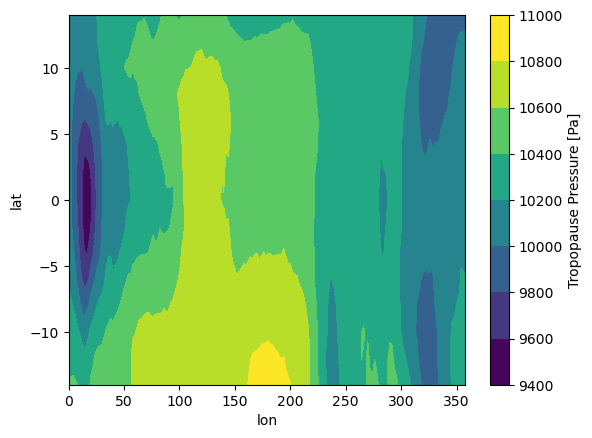

In [80]:
trop_field_cntl['tropopause_pressure'].mean('time').plot.contourf()

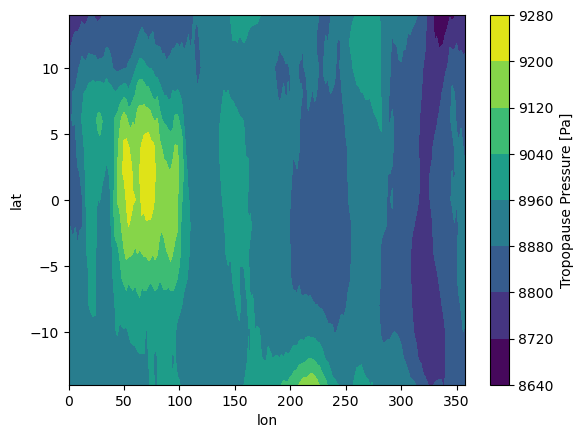

In [81]:
trop_field_p4k['tropopause_pressure'].mean('time').plot.contourf()

In [82]:
"""
统计分析对流层顶的空间分布特征
"""

# 计算时间平均
print("计算时间平均...")
trop_height_cntl_tmean = trop_field_cntl['tropopause_height'].mean(dim='time')
trop_height_p4k_tmean = trop_field_p4k['tropopause_height'].mean(dim='time')
trop_height_4co2_tmean = trop_field_4co2['tropopause_height'].mean(dim='time')

trop_temp_cntl_tmean = trop_field_cntl['tropopause_temperature'].mean(dim='time')
trop_temp_p4k_tmean = trop_field_p4k['tropopause_temperature'].mean(dim='time')
trop_temp_4co2_tmean = trop_field_4co2['tropopause_temperature'].mean(dim='time')

# 计算差异
trop_height_diff_p4k = trop_height_p4k_tmean - trop_height_cntl_tmean
trop_height_diff_4co2 = trop_height_4co2_tmean - trop_height_cntl_tmean


print("\n" + "="*90)
print("对流层顶高度统计（海洋格点，基于温度最小值）")
print("="*90)



计算时间平均...

对流层顶高度统计（海洋格点，基于温度最小值）


### 9.4 对流层顶空间分布图 (Spatial Distribution of Tropopause Height)

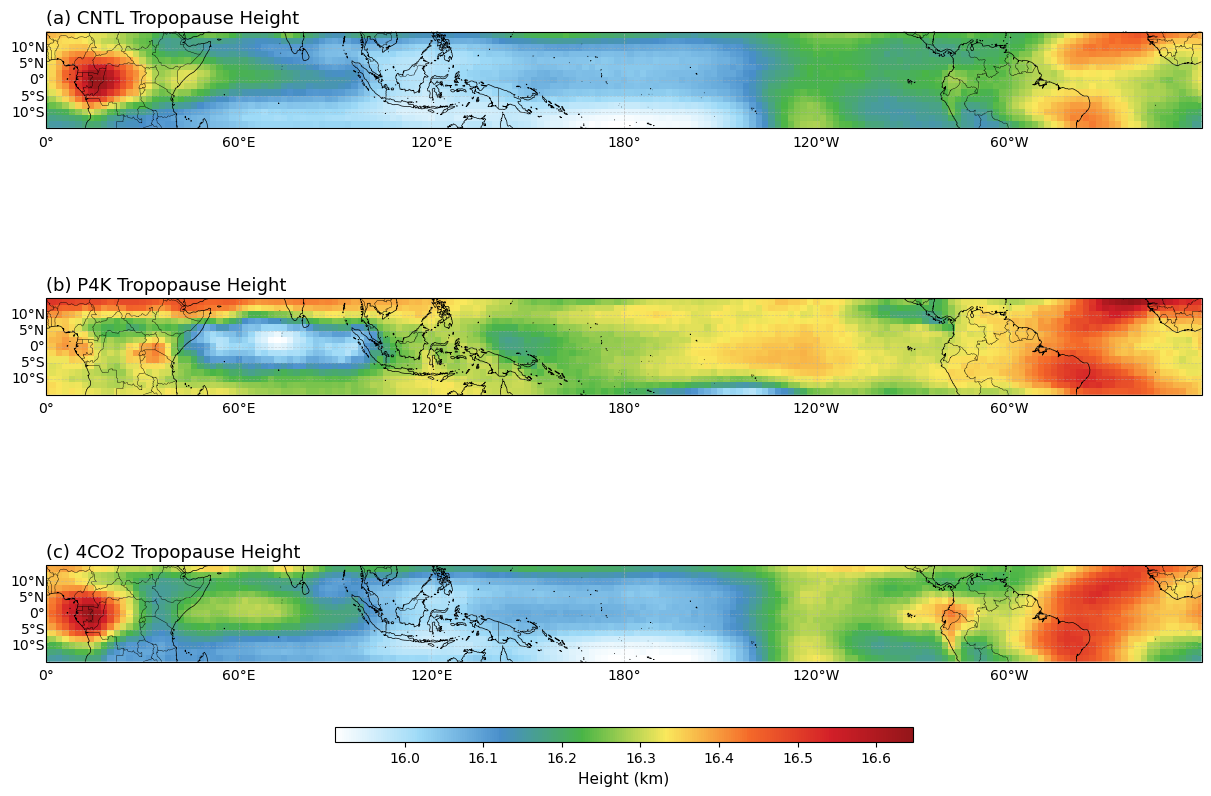

In [ ]:
import cartopy.crs as ccrs
import cmaps
import cartopy.feature as cfeature
# 投影
proj = ccrs.PlateCarree(180)


datasets = [
    (trop_height_cntl_tmean, '(a) CNTL Tropopause Height'),
    (trop_height_p4k_tmean, '(b) P4K Tropopause Height'),
    (trop_height_4co2_tmean, '(c) 4CO2 Tropopause Height')
]

fig, axes = plt.subplots(3, 1, figsize=(12, 9), subplot_kw={'projection': proj}, constrained_layout=True)

# 创建网格 (一次)
lats = trop_height_cntl_tmean[lat_dim].values
lons = trop_height_cntl_tmean[lon_dim].values
LON, LAT = np.meshgrid(lons, lats)

for ax, (data, title) in zip(axes, datasets):
    cf = ax.pcolormesh(LON, LAT, data/1000, 
                       cmap=cmaps.WhiteBlueGreenYellowRed,
                       transform=ccrs.PlateCarree(),
                       shading='auto')
    ax.coastlines(linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.set_title(title, fontsize=13,loc='left')
    
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False

# 共享 colorbar
cbar = fig.colorbar(cf, ax=axes, orientation='horizontal', pad=0.05, aspect=40, shrink=0.5)
cbar.set_label('Height (km)', fontsize=11)

plt.savefig(fig_save_dir + 'tropopause_height_maps.png', dpi=300, bbox_inches='tight')
plt.show()

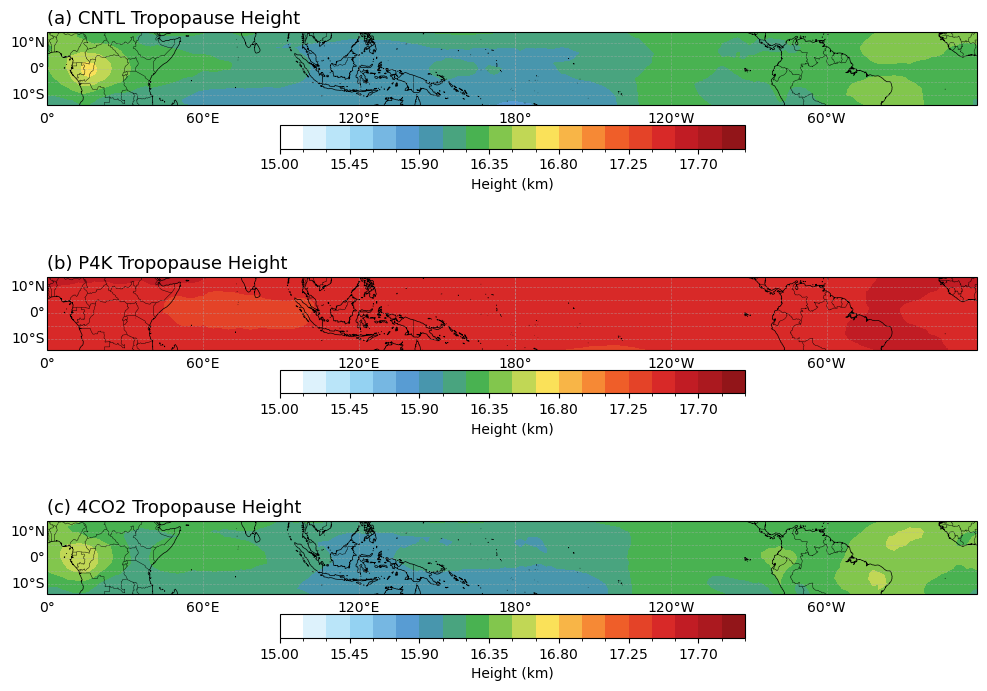

In [89]:
proj = ccrs.PlateCarree(180)
fig, axes = plt.subplots(3, 1, figsize=(12, 9), subplot_kw={'projection': proj})

# 创建网格 (一次)
lats = trop_height_cntl_tmean[lat_dim].values
lons = trop_height_cntl_tmean[lon_dim].values
LON, LAT = np.meshgrid(lons, lats)

for ax, (data, title) in zip(axes, datasets):
    cf = (data/1000).plot.contourf(ax=ax, transform=ccrs.PlateCarree(), cmap=cmaps.WhiteBlueGreenYellowRed,
                            levels = np.linspace(15, 18, 21),
                            cbar_kwargs={'label': 'Height (km)', 'shrink': 0.5,
                                         'orientation': 'horizontal', 'pad': 0.1}
                            )
    
    ax.coastlines(linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.set_title(title, fontsize=13,loc='left')
    
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False


plt.savefig(fig_save_dir + 'tropopause_height_maps.png', dpi=300, bbox_inches='tight')
plt.show()

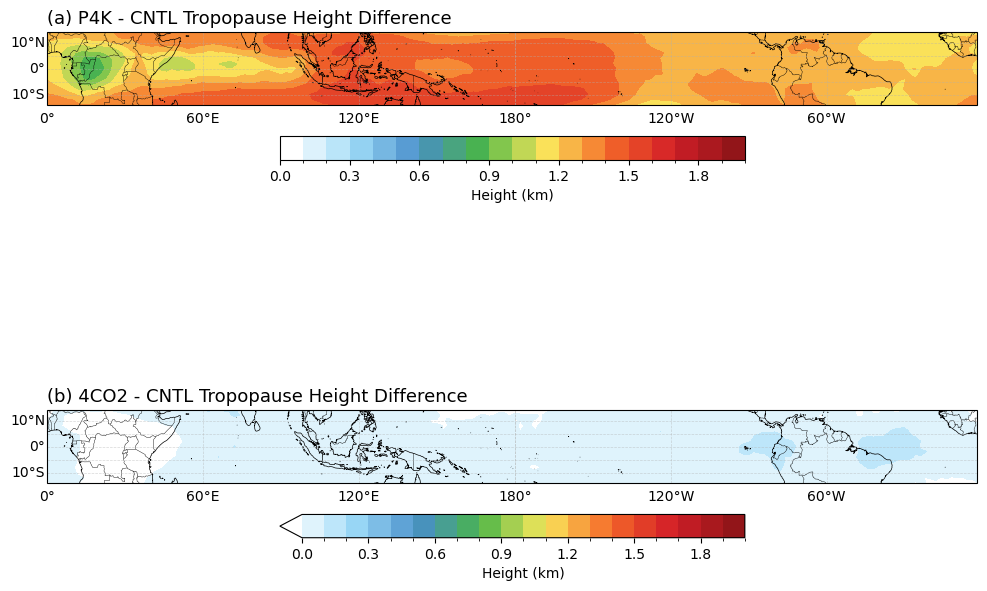

In [91]:
proj = ccrs.PlateCarree(180)

datasets_diff = [
    (trop_height_diff_p4k, '(a) P4K - CNTL Tropopause Height Difference'),
    (trop_height_diff_4co2, '(b) 4CO2 - CNTL Tropopause Height Difference')
]   

fig, axes = plt.subplots(2, 1, figsize=(12, 9), subplot_kw={'projection': proj})

# 创建网格 (一次)
lats = trop_height_cntl_tmean[lat_dim].values
lons = trop_height_cntl_tmean[lon_dim].values
LON, LAT = np.meshgrid(lons, lats)

for ax, (data, title) in zip(axes, datasets_diff):
    cf = (data/1000).plot.contourf(ax=ax, transform=ccrs.PlateCarree(), cmap=cmaps.WhiteBlueGreenYellowRed,
                            levels = np.linspace(0, 2, 21),
                            cbar_kwargs={'label': 'Height (km)', 'shrink': 0.5,
                                         'orientation': 'horizontal', 'pad': 0.1}
                            )
    
    ax.coastlines(linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.set_title(title, fontsize=13,loc='left')
    
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False


plt.savefig(fig_save_dir + 'tropopause_height_maps_diff.png', dpi=300, bbox_inches='tight')
plt.show()